# Quantum linear solver based on QSVT

The code here can be integrated as part of a larger CFD solver, e.g., as in [qc-cfd repository](https://github.com/rolls-royce/qc-cfd/tree/main/1D-Nozzle).
In particular, instead of calling a classical solver, e.g., `x = sparse.linalg.spsolve(mat_raw_scr, b_raw)`, one can call the quantum solver `qsvt_solver(mat_raw_scr, b_raw,...)`.

We implemented two versions for block-encoding, one based on Pauli decomposition of the matrix, and another one based on decomposing the matrix to a finite set of diagonals.

In [1]:
!pip install -qq -U "classiq[qsp]"
!pip install -qq "classiq[chemistry]"

We start with defining the main function `qsvt_solver`, which gets the matrix and right-hand-side vector, applies the quantum solver, and returns the linear equation solution using a statevector simulator. 

The solvers in this directory were developed in the framework of exploring their performance in hybrid CFD schemes. For simplicity, it is assumed that all the properties of the matrices are known explicitly. In particular, we calculate its singular values for identifying the range in which we apply the inversion polynomial.

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
from banded_be import get_banded_diags_be
from cheb_utils import *
from classical_functions_be import get_svd_range
from pauli_be import get_pauli_be
from scipy import sparse

from classiq import *
from classiq.applications.qsp import qsvt_phases
from classiq.applications.qsp.qsp import poly_inversion

np.random.seed(53)

PAULI_TRIM_REL_TOL = 0.1

In [3]:
def qsvt_solver(
    mat_raw_scr,
    b_raw,
    poly_degree,
    be_method="banded",
    preferences=Preferences(),
    constraints=Constraints(),
):

    scale = 0.5
    b_norm = np.linalg.norm(b_raw)  # b normalization
    b_normalized = b_raw / b_norm

    # Define block encoding
    if be_method == "pauli":
        data_size, block_size, be_scaling_factor, be_qfunc = get_pauli_be(
            mat_raw_scr, PAULI_TRIM_REL_TOL
        )
        print(
            f"Pauli block encoding with block size {block_size} and scaling factor {be_scaling_factor}"
        )

    elif be_method == "banded":
        data_size, block_size, be_scaling_factor, be_qfunc = get_banded_diags_be(
            mat_raw_scr
        )
        print(
            f"Banded diagonal block encoding with block size {block_size} and scaling factor {be_scaling_factor}"
        )

    class BlockEncodedState(QStruct):
        data: QNum[data_size]
        block: QNum[block_size]

    # Get SVD range
    w_min, w_max = get_svd_range(mat_raw_scr / be_scaling_factor)
    # Get Chebyshev polynomial and the corresponding QSVT angles
    c, m = poly_inversion(poly_degree, 1 / w_min, "relative")
    pcoefs, poly_scale = scale * c / m, scale / m
    inv_phases = qsvt_phases(pcoefs)

    # Define QSVT projector
    @qfunc
    def projector(be: BlockEncodedState, res: QBit):
        res ^= be.block == 0

    @qfunc
    def main(
        qsvt_aux: Output[QBit],
        data: Output[QNum[data_size]],
        block: Output[QNum[block_size]],
    ):
        allocate(qsvt_aux)
        allocate(block)
        prepare_amplitudes(b_normalized.tolist(), 0, data)

        be_state = BlockEncodedState()

        within_apply(
            lambda: bind([data, block], be_state),
            lambda: qsvt_inversion(
                inv_phases,
                lambda aux: projector(be_state, aux),
                lambda: be_qfunc(be_state.block, be_state.data),
                qsvt_aux,
            ),
        )

    start_time_syn = time.time()
    qprog = synthesize(main, preferences=preferences, constraints=constraints)
    print("time to syn:", time.time() - start_time_syn)

    start_time_exe = time.time()
    sv = calculate_state_vector(qprog, filters={"block": 0, "qsvt_aux": 0})
    proj_statevector = np.zeros(2**data_size, dtype=complex)
    proj_statevector[sv["data"].to_numpy()] = sv["amplitude"].to_numpy()
    indices = np.where(np.abs(proj_statevector) > 1e-13)[0]
    if len(indices) > 0:
        global_phase = np.angle(proj_statevector[indices[0]])
        resulting_state = np.real(proj_statevector / np.exp(1j * global_phase))
    else:
        resulting_state = np.zeros(2**data_size)
    print("time to exe:", time.time() - start_time_exe)

    normalization_factor = (be_scaling_factor * poly_scale) / b_norm

    return resulting_state / normalization_factor, qprog

We examine two usecases, starting with a small one, and applying a Pauli-LCU block encoding.

In [4]:
prefs = Preferences()

In [5]:
import pathlib

path = (
    pathlib.Path(__file__).parent.resolve()
    if "__file__" in locals()
    else pathlib.Path(".")
)

In [6]:
mat_small_scr = sparse.load_npz(path / "matrices/nozzle_small_scr.npz")
b_small = np.load(path / "matrices/b_nozzle_small.npy")
print(f"nozzle_small: {mat_small_scr.shape[0]}x{mat_small_scr.shape[1]}")

nozzle_small: 8x8


In [7]:
qsol_small_pauli, qprog_small_pauli = qsvt_solver(
    mat_small_scr,
    b_small,
    poly_degree=101,
    be_method="pauli",
    preferences=prefs,
    constraints=Constraints(optimization_parameter="width"),
)
show(qprog_small_pauli)

number of Paulis before/after trimming 24/20
Pauli block encoding with block size 5 and scaling factor 5.557119918538639


Submitting job to simulator


time to syn: 194.59005403518677


Job: https://platform.classiq.io/jobs/2770fe10-ee32-4dbf-8eb5-3d5929996e44


time to exe: 21.43983793258667
Quantum program link: https://platform.classiq.io/circuit/3DqBaa1JyKpdP4PL71mpJcJufY9


We plot the solution vector, and compare to the expected classical result:

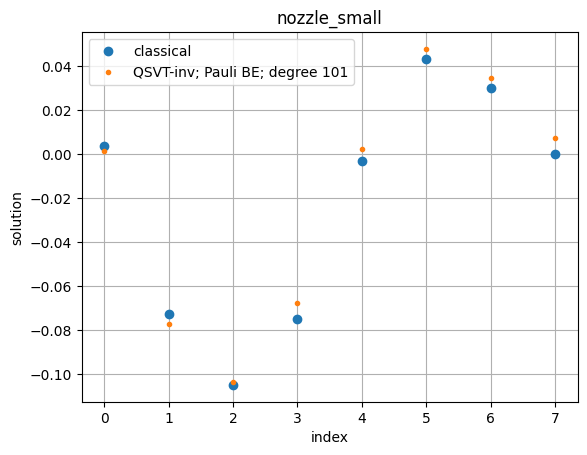

In [8]:
expected_small = np.linalg.solve(mat_small_scr.toarray(), b_small)
ext_idx = np.argmax(np.abs(expected_small))
correct_sign = np.sign(expected_small[ext_idx]) / np.sign(qsol_small_pauli[ext_idx])
qsol_small_pauli *= correct_sign
plt.plot(expected_small, "o", label="classical")
plt.plot(qsol_small_pauli, ".", label="QSVT-inv; Pauli BE; degree 101")
plt.title("nozzle_small")
plt.xlabel("index")
plt.ylabel("solution")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
assert np.linalg.norm(qsol_small_pauli - expected_small) < 0.1

Next, we move to a larger problem. In a hybrid algorithm, we can relax some of the synthesis preferences to obtain the result a faster (for example, we can set `debug_mode=False` as we can skip the visualization of the quantum program).
For the larger usecase we work with the Banded Diagonals block-encoding. We compare the approximated version of the solver to the exact one.

In [10]:
mat_008_scr = sparse.load_npz(path / "matrices/nozzle_008_mat.npz")
b_008 = np.load(path / "matrices/nozzle_008_b.npy")
print(f"nozzle_008:   {mat_008_scr.shape[0]}x{mat_008_scr.shape[1]}")

nozzle_008:   16x16


In [15]:
prefs = Preferences(
    transpilation_option="none",
    optimization_level=0,
    debug_mode=False,
    qasm3=True,
)

In [16]:
qsol_008_banded, qprog_008_banded = qsvt_solver(
    mat_008_scr,
    b_008,
    poly_degree=2 * (2**7 - 1) + 1,  # taking the same degree as in qls_chebyshev_lcu
    be_method="banded",
    preferences=prefs,
    constraints=Constraints(optimization_parameter="width"),
)

Banded diagonal block encoding with block size 4 and scaling factor 6.097617696340303


Submitting job to simulator


time to syn: 169.09099125862122


Job: https://platform.classiq.io/jobs/1011bac7-83f6-4790-a63e-cbc32c8b9fec


time to exe: 95.1099259853363


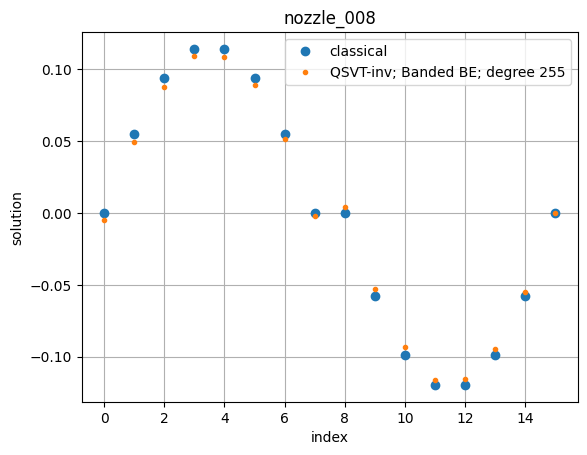

In [17]:
expected_008 = np.linalg.solve(mat_008_scr.toarray(), b_008)
ext_idx = np.argmax(np.abs(expected_008))
correct_sign = np.sign(expected_008[ext_idx]) / np.sign(qsol_008_banded[ext_idx])
qsol_008_banded *= correct_sign
plt.plot(expected_008, "o", label="classical")
plt.plot(qsol_008_banded, ".", label=f"QSVT-inv; Banded BE; degree {2*(2**7-1)+1}")
plt.title("nozzle_008")
plt.xlabel("index")
plt.ylabel("solution")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
assert np.linalg.norm(qsol_008_banded - expected_008) < 0.1